In [2]:
import pandas as pd
import numpy as np
import re
import spacy
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from textblob import TextBlob
from transformers import BertTokenizer
from collections import Counter

# Load Spacy Model for NER
nlp = spacy.load("en_core_web_sm")

# Load BERT Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]  # Remove stopwords
    return ' '.join(words)

def extract_named_entities(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # Returns a score between -1 and 1

# Load dataset with proper dtypes to prevent scientific notation
df = pd.read_csv("black_lives_matter.csv", dtype={"id": str, "reply_to_id": str, "conversation_id": str})

# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Drop duplicates
df.drop_duplicates(inplace=True)

# Remove rows only if 'text' column is empty
df = df[df['text'].notna() & (df['text'].str.strip() != '')]

# Apply text preprocessing
df['cleaned_text'] = df['text'].apply(preprocess_text)
df['named_entities'] = df['text'].apply(extract_named_entities)
df['sentiment'] = df['text'].apply(get_sentiment)

# Convert reply_to_id to integer format (remove scientific notation)
df["reply_to_id"] = df["reply_to_id"].apply(lambda x: str(x).strip() if pd.notna(x) and str(x).strip().isdigit() else "0")


# Replace empty reply_to_nm with "None"
df["reply_to_nm"] = df["reply_to_nm"].fillna("None").astype(str)
df.loc[df["reply_to_nm"].str.strip() == "", "reply_to_nm"] = "None"

# Convert timestamp format to 'YYYY-MM-DD HH:MM:SS'
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce').dt.strftime('%Y-%m-%d %H:%M:%S')

# Tokenization using BERT
df['tokens'] = df['cleaned_text'].apply(lambda x: tokenizer.encode(x, add_special_tokens=True))

# Save processed data
df.to_csv("new_processed_tweets_black_lives.csv", index=False)

print("✅ Processing complete. Data saved as 'processed_tweets.csv'")

✅ Processing complete. Data saved as 'processed_tweets.csv'


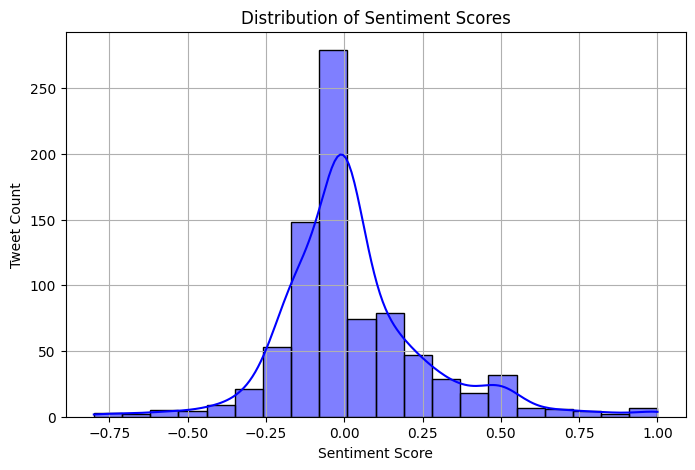

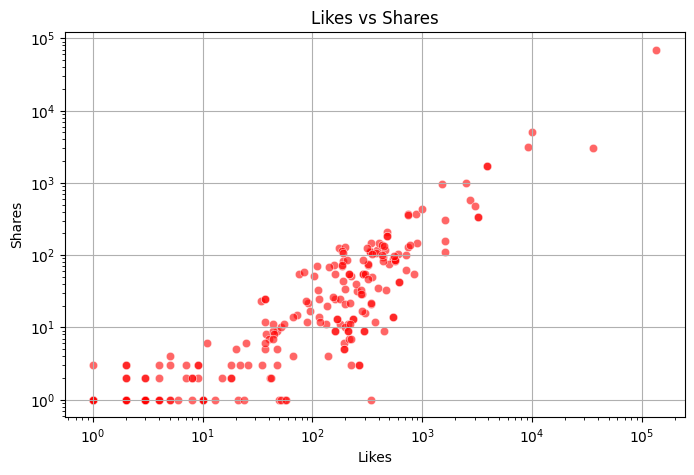

/var/folders/b_/gz05y8hn2pxdk1r0nf6_fj8w0000gn/T/ipykernel_19629/3405272587.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(entities), palette="coolwarm")


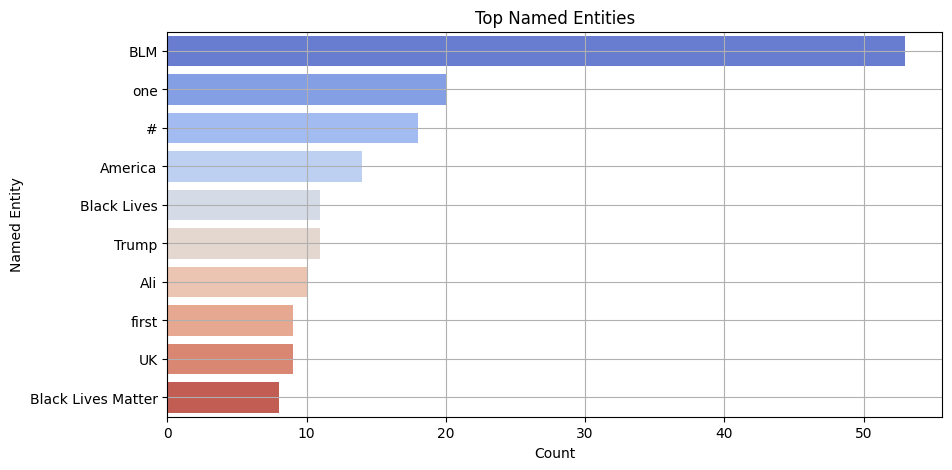

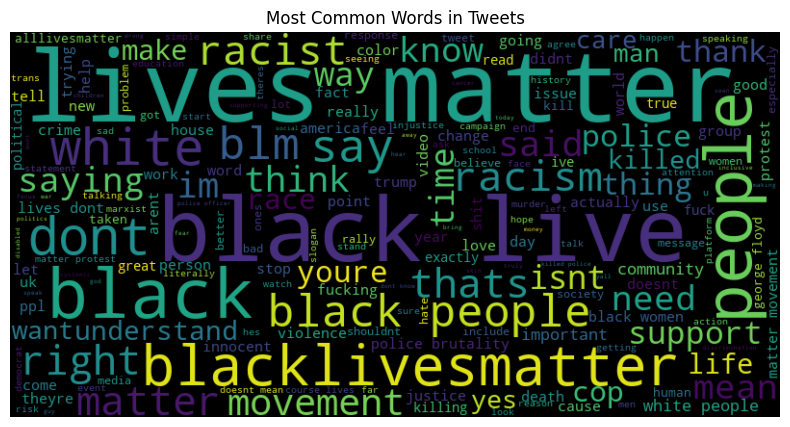

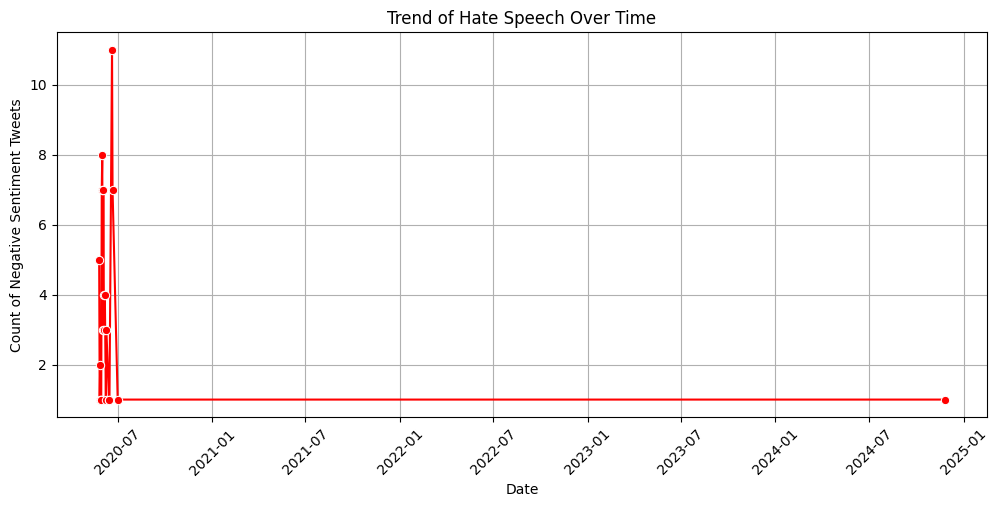

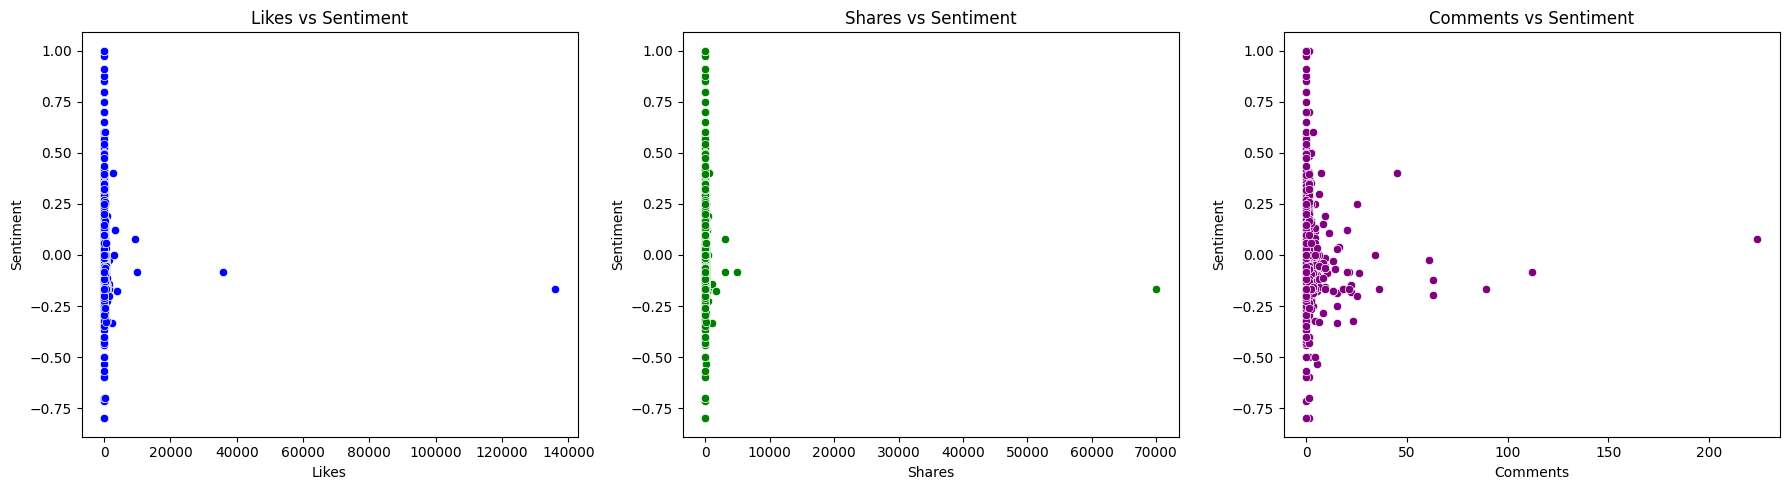

In [3]:
##VISUALISE DATA-

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import ast  # To convert string representations of lists back to lists

# Load dataset
df = pd.read_csv("new_processed_tweets_black_lives.csv")

# Convert timestamp to proper datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Convert named_entities from string to list of tuples (if needed)
df["named_entities"] = df["named_entities"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# 1️⃣ Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["sentiment"], bins=20, kde=True, color="blue")
plt.xlabel("Sentiment Score")
plt.ylabel("Tweet Count")
plt.title("Distribution of Sentiment Scores")
plt.grid()
plt.show()

# 2️⃣ Scatter Plot of Likes vs Shares (Ensure no NaN values)
df_filtered = df.dropna(subset=["likes", "shares"])
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_filtered["likes"], y=df_filtered["shares"], alpha=0.6, color="red")
plt.xlabel("Likes")
plt.ylabel("Shares")
plt.title("Likes vs Shares")
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.show()

# 3️⃣ Most Common Named Entities
all_entities = [entity[0] for sublist in df["named_entities"] for entity in sublist]  # Extract entity names
entity_counts = Counter(all_entities).most_common(10)  # Get top 10 entities
entities, counts = zip(*entity_counts) if entity_counts else ([], [])

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(entities), palette="coolwarm")
plt.xlabel("Count")
plt.ylabel("Named Entity")
plt.title("Top Named Entities")
plt.grid()
plt.show()

# 4️⃣ Word Cloud of Cleaned Text
text = " ".join(df["cleaned_text"].dropna())  # Combine all cleaned text
wordcloud = WordCloud(width=800, height=400, background_color="black").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Tweets")
plt.show()

# 5️⃣ Trend of Negative Sentiment Over Time
df['date'] = df['timestamp'].dt.date  # Extract only date
time_series = df[df['sentiment'] < -0.2].groupby('date').size()

plt.figure(figsize=(12, 5))
sns.lineplot(x=time_series.index, y=time_series.values, marker='o', color='red')
plt.xlabel("Date")
plt.ylabel("Count of Negative Sentiment Tweets")
plt.title("Trend of Hate Speech Over Time")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 6️⃣ Most Engaged Tweets - Sentiment vs Engagement
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Likes vs Sentiment
sns.scatterplot(ax=axes[0], x=df_filtered['likes'], y=df_filtered['sentiment'], color='blue')
axes[0].set_title("Likes vs Sentiment")
axes[0].set_xlabel("Likes")
axes[0].set_ylabel("Sentiment")

# Shares vs Sentiment
sns.scatterplot(ax=axes[1], x=df_filtered['shares'], y=df_filtered['sentiment'], color='green')
axes[1].set_title("Shares vs Sentiment")
axes[1].set_xlabel("Shares")
axes[1].set_ylabel("Sentiment")

# Comments vs Sentiment
sns.scatterplot(ax=axes[2], x=df_filtered['num_comments'], y=df_filtered['sentiment'], color='purple')
axes[2].set_title("Comments vs Sentiment")
axes[2].set_xlabel("Comments")
axes[2].set_ylabel("Sentiment")

plt.tight_layout()
plt.show()
